In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

Total samples in dataset: 19675
Extracted Spatial Field 'a' Shape: (128, 128)
Extracted Boundary Condition 'bc' Value: 0.4713
Extracted Solution 'u' Shape: (128, 128)


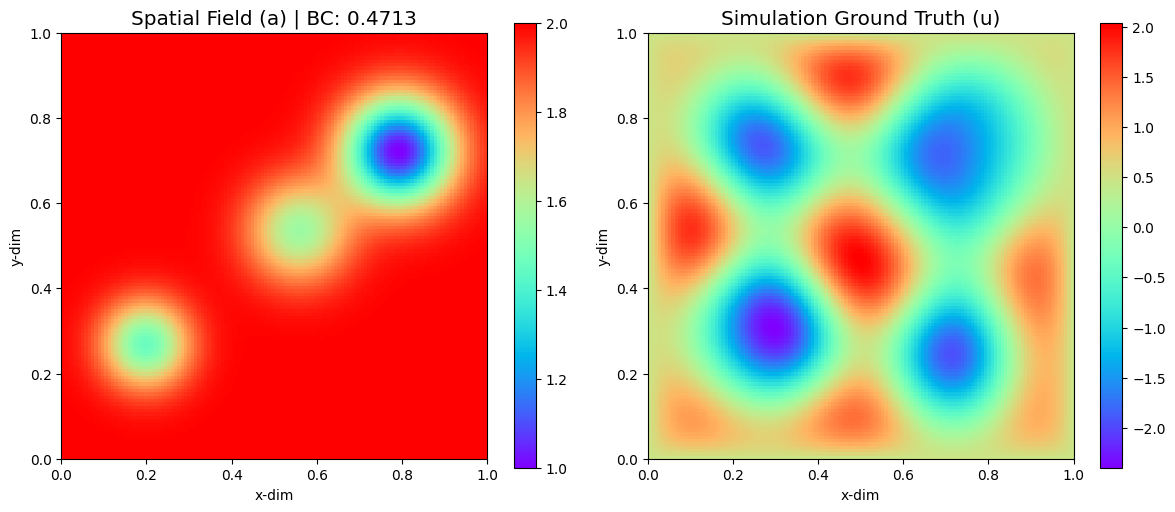

In [3]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    print(f"Total samples in dataset: {len(f.keys())}")
    
    # In the Helmholtz dataset, each sample contains 'a', 'bc', and 'u'
    a_sample = f[sample_key]['a'][:]
    bc_sample = f[sample_key]['bc'][()]
    u_sample = f[sample_key]['u'][:]

print(f"Extracted Spatial Field 'a' Shape: {a_sample.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_sample.shape}")

# Visualization (Mirroring your original plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting 'a' (the spatial dependent function)
im1 = axes[0].imshow(a_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im1, ax=axes[0])
axes[0].set_title(f'Spatial Field (a) | BC: {bc_sample:.4f}', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

# Plotting 'u' (the solution)
im2 = axes[1].imshow(u_sample.T, origin='lower', cmap='rainbow', extent=[0, 1, 0, 1])
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [4]:
class HelmholtzDataset(Dataset):
    def __init__(self, file_path, start_idx, end_idx):
        self.file_path = file_path
        self.start_idx = start_idx
        self.end_idx = end_idx
        self.length = end_idx - start_idx

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        actual_idx = self.start_idx + idx
        sample_key = f"Sample_{actual_idx}"
        
        with h5py.File(self.file_path, 'r') as f:
            a_data = f[sample_key]['a'][:]
            bc_data = f[sample_key]['bc'][()] 
            u_data = f[sample_key]['u'][:]
            
        # Reshape (128, 128) to (16384, 1)
        a_flat = a_data.reshape(-1, 1)
        u_flat = u_data.reshape(-1, 1)
        
        return a_flat, u_flat, bc_data

n_train = 19035
n_val = 128
n_test = 512

train_dataset = HelmholtzDataset(FILE_PATH, 0, n_train)
val_dataset = HelmholtzDataset(FILE_PATH, n_train, n_train + n_val)
test_dataset = HelmholtzDataset(FILE_PATH, n_train + n_val, n_train + n_val + n_test)

batch_size_samples = 8
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True, num_workers=0)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False, num_workers=0 )
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False, num_workers=0 )

print("DataLoaders ready!")

DataLoaders ready!


In [5]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
# Note: We no longer create a static `u_bc` array of zeros here, because the boundary value `bc` changes per sample and will be passed from the dataloader.

E0702 09:14:54.692577  108235 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0702 09:14:54.703350  108012 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [6]:
epochs = 1
M = 512 # Increased to give the network a wider basis dictionary
chunk_size = 256 
hidden_layers = [256, 256, 256, 256] # Widened the hidden layers
total_features = (2 * M) + sum(hidden_layers) # 1024

sigma = 3 
rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma 

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        self.param('raw_lambda', nn.initializers.constant(-3.0), (1,)) 
        
        v = jnp.concatenate([x_in, y_in])

        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = jnp.sin(h) 
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
        return combined_h
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

# Dummy initialization
key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2, -3))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2, -3))
    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_xx_chunk, f_yy_chunk

def get_u(params, x_val, y_val, w_current):
    f = model.apply(params, x_val, y_val)
    return jnp.dot(f, w_current) 

def get_u_dir(params, x_val, y_val, w_current):
    u_xx = jacfwd(jacfwd(get_u, argnums=1), argnums=1)(params, x_val, y_val, w_current)
    u_yy = jacfwd(jacfwd(get_u, argnums=2), argnums=2)(params, x_val, y_val, w_current)
    
    u_xx = jnp.squeeze(u_xx, axis=(-1, -2))
    u_yy = jnp.squeeze(u_yy, axis=(-1, -2))
    return u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [8]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)

# Frequency defined in the paper B.2.15
omega = 5.0 * jnp.pi / 2.0 

def compute_loss_single(params, w_current, x_batch, y_batch, a_single, x_bc, y_bc, bc_val, u_single):
    u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    pde_residual = laplacian_u + (omega**2) * a_single * u_pred_interior
    loss_pde = jnp.mean(pde_residual ** 2)
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    loss_bc = jnp.mean((u_bc_pred - bc_val) ** 2) * 10000.0
    
    # NEW: Data Loss term to force the SIREN to learn the waves
    loss_data = jnp.mean((u_pred_interior - u_single) ** 2) * 10000.0
    
    # Sum all three losses
    return loss_pde + loss_bc + loss_data

# Update the vmap to accept the 9th argument (u_single) along axis 0
batched_compute_loss = jax.vmap(
    compute_loss_single, 
    in_axes=(None, 0, None, None, 0, None, None, 0, 0)
)

In [9]:
def get_A_and_b_single(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val, total_features, chunk_size):
    A_chunks = []
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        f_chunk = f_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # Matrix A corresponding to the PDE operator
        A_pde_chunk = f_xx + f_yy + (omega**2) * a_pde * f_chunk
        
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(1e5)
        
        A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
        A_chunks.append(A_chunk)
        
    A_full = jnp.hstack(A_chunks)
    
    # Target vector b
    b_pde = jnp.zeros_like(a_pde) # RHS is 0 for Helmholtz
    b_bc = jnp.ones_like(x_bc) * bc_val * jnp.sqrt(1e5)
    b_full = jnp.vstack([b_pde, b_bc])
    
    return A_full, b_full

batched_get_A_and_b = jax.vmap(
    get_A_and_b_single, 
    # params, x_pde, y_pde, a_batch, x_bc, y_bc, bc_batch, total_features, chunk_size
    in_axes=(None, None, None, 0, None, None, 0, None, None) 
)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve_batch(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, total_features, chunk_size, tik_reg=1e-5):
    A_batch, b_batch = batched_get_A_and_b(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, total_features, chunk_size)
    
    def solve_single(A, b):
        AtA = A.T @ A + tik_reg * jnp.eye(total_features)
        Atb = A.T @ b
        return jnp.linalg.solve(AtA, Atb)
    
    w_batch = jax.vmap(solve_single)(A_batch, b_batch)
    return w_batch

In [10]:
def full_forward_and_loss(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, u_batch, total_features, chunk_size):
    raw_val = params['params']['raw_lambda'][0]
    tik_reg = 10 ** (jnp.tanh(raw_val) * 3 - 2) 
    
    w_batch = update_direct_solve_batch(
        params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, total_features, chunk_size, tik_reg
    )
    
    # Pass u_batch into the loss function
    batched_loss = batched_compute_loss(
        params, w_batch, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, u_batch
    )
    return jnp.mean(batched_loss), tik_reg

loss_grad_fn = jax.jit(
    value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size']
)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, u_batch, total_features, chunk_size):
    (loss, current_lambda), grads = loss_grad_fn(
        params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_batch, u_batch, total_features, chunk_size
    )
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss, current_lambda

# --- EVALUATION FUNCTION ---
@jax.jit
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch):
    # Calculate universal basis functions for the grid -> Shape: (16384, 1024)
    f_grid = f_spatial_vmap(params, x_grid, y_grid)
    
    # Batched matmul over the weights -> Shape: (8, 16384, 1)
    u_pred_batch = jnp.einsum('nf,bfm->bnm', f_grid, w_batch)
    
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_grid, y_grid):
    total_mse = 0.0
    total_samples = 0
    
    # Grab 1000 random points across the whole grid for the solver
    rng = jax.random.PRNGKey(0)
    total_points = x_grid.shape[0]
    val_spatial_idx = jax.random.choice(rng, jnp.arange(total_points), shape=(4000,), replace=False)
    
    test_x_chunk = x_grid[val_spatial_idx]
    test_y_chunk = y_grid[val_spatial_idx]
    
    for a_batch, u_batch, bc_batch in dataloader:
        a_chunk_val = a_batch[:, val_spatial_idx, :]
        
        raw_val = params['params']['raw_lambda'][0]
        learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)
        
        w_val = update_direct_solve_batch(
            params, test_x_chunk, test_y_chunk, a_chunk_val, 
            x_bc, y_bc, bc_batch, total_features, chunk_size, learned_lambda
        )
       
        batch_mse = fast_eval_step(params, w_val, x_grid, y_grid, u_batch)
        
        current_batch_size = a_batch.shape[0]
        total_mse += batch_mse.item() * current_batch_size
        total_samples += current_batch_size
            
    return total_mse / total_samples

In [11]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0] # 16384
spatial_batch_size = 4000 

total_bc_points = x_bc.shape[0]
bc_batch_size = 1000

rng, pde_shuffle_key, bc_shuffle_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_shuffle_key, total_points)
bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)

ptr = 0
bc_ptr = 0 

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for a_batch, u_batch, bc_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

        # Sample Interior PDE Points
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        
        x_chunk = x[batch_idx]
        y_chunk = y[batch_idx]
        a_chunk = a_batch[:, batch_idx, :] 
        u_chunk = u_batch[:, batch_idx, :]
        
        # Sample Boundary Points
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        
        x_bc_chunk = x_bc[bc_batch_idx]
        y_bc_chunk = y_bc[bc_batch_idx]
        
        # Network update
        params, opt_state, loss, current_lambda = update_network(
            params, opt_state, 
            x_chunk, y_chunk, a_chunk, 
            x_bc_chunk, y_bc_chunk, bc_batch, u_chunk, 
            total_features, chunk_size
        )
        
        epoch_loss += loss
        num_batches += 1
            
    avg_train_loss = epoch_loss / num_batches
    val_mse = evaluate_dataset(val_dataloader, params, x, y)
    
    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4e} | Val MSE: {val_mse:.4e} | TikReg: {current_lambda:.2e}")

Epoch 1/1:   0%|          | 0/2379 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 1.2106e+04 | Val MSE: 1.1554e+00 | TikReg: 1.03e-05


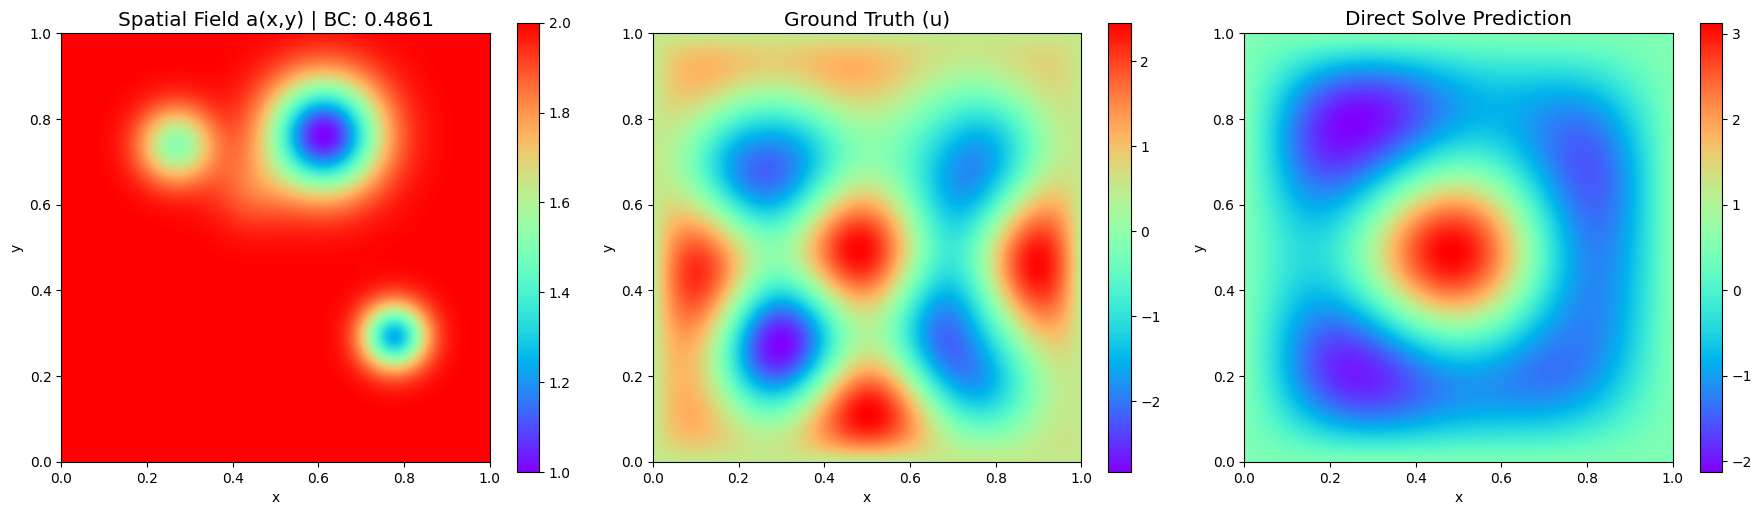

In [13]:
test_sample_idx =32
a_sample, u_sim_sample, bc_sample = test_dataset[test_sample_idx]

# Add batch dimension for the solver
a_batch = jnp.array(a_sample[None, ...])
bc_batch = jnp.array([bc_sample])

raw_val = params['params']['raw_lambda'][0]
learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)

# Grab 1000 random points to solve for w_plot
rng_plot = jax.random.PRNGKey(1)
plot_spatial_idx = jax.random.choice(rng_plot, jnp.arange(nx * ny), shape=(4000,), replace=False)

w_plot = update_direct_solve_batch(
    params, 
    x[plot_spatial_idx], 
    y[plot_spatial_idx], 
    a_batch[:, plot_spatial_idx, :], 
    x_bc, y_bc, bc_batch, 
    total_features, chunk_size, learned_lambda
)

# Predict full grid
f_features = f_spatial_vmap(params, x, y)
u_pred = f_features @ w_plot[0]

# Reshape for plotting
a_plot = a_sample.reshape(nx, ny).T
u_sim_plot = u_sim_sample.reshape(nx, ny).T 
u_pred_plot = np.array(u_pred.reshape(nx, ny).T)

ext = [0, 1, 0, 1]
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
mesh1 = ax1.imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
mesh2 = ax2.imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Ground Truth (u)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
mesh3 = ax3.imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Direct Solve Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()